# 📝 Actividad de Evaluación: Análisis Exploratorio de Portafolios (10%)

**Instrucciones:**
1. Resuelve cada uno de los puntos solicitados utilizando código de Python limpio y ordenado.
2. No olvides acompañar cada visualización con su respectiva **interpretación analítica** (recuerda la regla de oro: qué observas y qué significa).
3. Puedes realizar esta actividad de forma individual o en parejas (según las indicaciones del docente).

---

## 🏦 Paso 1: Selección y Descarga de Datos

1. Selecciona **3 activos financieros** diferentes a los utilizados en la clase (evita usar AAPL, MSFT, GOOGL, AMZN o NVDA).
2. Descarga los datos históricos utilizando `yfinance` para el periodo del **1 de enero de 2024** al **1 de enero de 2026**.
3. Muestra las primeras 5 filas del DataFrame resultante para validar la descarga.

In [34]:
import yfinance as yf

tickers = ['KO', 'JPM', 'DIS']

datos = yf.download(tickers, start='2024-01-01', end='2026-01-01')

datos.head()

/tmp/ipykernel_2015/3560217152.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(tickers, start='2024-01-01', end='2026-01-01')
[*********************100%***********************]  3 of 3 completed


Price           Close                              High              \
Ticker            DIS         JPM         KO        DIS         JPM   
Date                                                                  
2024-01-02  88.235725  162.278290  55.309338  88.984726  162.363160   
2024-01-03  89.150070  161.570999  55.438774  89.568341  162.240549   
2024-01-04  88.089798  162.643204  55.253857  89.432161  164.483984   
2024-01-05  88.420525  163.459244  55.170639  88.829066  164.512473   
2024-01-08  89.052795  163.222031  55.577461  89.432157  163.544638   

Price                        Low                              Open  \
Ticker             KO        DIS         JPM         KO        DIS   
Date                                                                 
2024-01-02  55.364815  87.282461  159.288855  54.246051  87.642364   
2024-01-03  55.660679  87.545076  160.665675  55.253854  87.768805   
2024-01-04  55.716155  87.545075  161.817690  55.161398  89.432161   
2024-01-05  55.429528  87.895253  162.700157  54.634375  87.943892   
2024-01-08  55.642183  88.517795  160.821429  54.939488  89.052795   

Price                                Volume                      
Ticker             JPM         KO       DIS       JPM        KO  
Date                                                             
2024-01-02  159.458596  54.366249  10587600   9977400  16322600  
2024-01-03  162.070809  55.411037  11929800   9852300  14830600  
2024-01-04  161.912581  55.521990  12087400  11972500  12912900  
2024-01-05  162.700157  55.290838   9092100  10066000  10412800  
2024-01-08  163.222031  55.179885  11103700  11229900  11554600

## 📈 Paso 2: Análisis de Precios de Cierre y Normalización

1. Filtra y extrae únicamente los precios de cierre (`Close`).
2. Grafica en una sola figura la evolución temporal de los precios originales de tus 3 activos.
3. Realiza la normalización (base 100 en el primer registro) y grafica nuevamente las series en otra figura.

### 💬 Pregunta de interpretación #1:
Al comparar ambos gráficos (precios reales vs. precios normalizados), ¿por qué es metodológicamente más correcto utilizar el gráfico normalizado para comparar el rendimiento histórico de los activos? Explica la diferencia en el comportamiento visual observado.

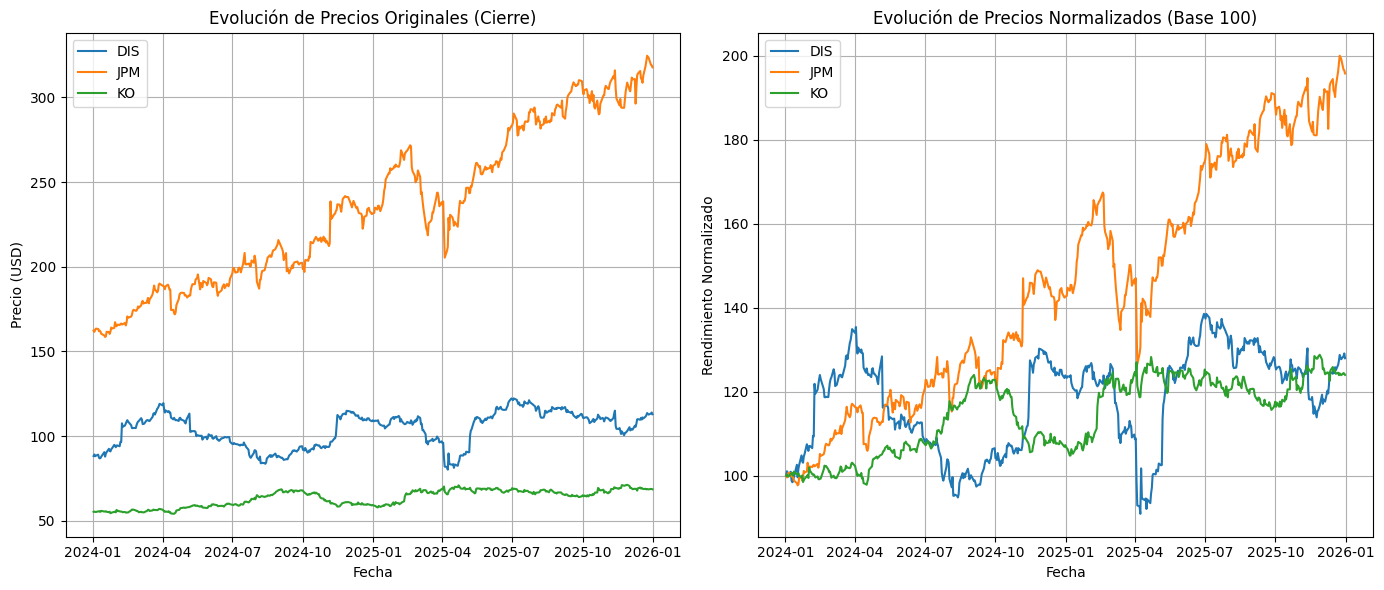

In [35]:
import matplotlib.pyplot as plt
precios_cierre = datos['Close']


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for col in precios_cierre.columns:
    plt.plot(precios_cierre.index, precios_cierre[col], label=col)
plt.title('Evolución de Precios Originales (Cierre)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)


precios_normalizados = (precios_cierre / precios_cierre.iloc[0]) * 100

plt.subplot(1, 2, 2)
for col in precios_normalizados.columns:
    plt.plot(precios_normalizados.index, precios_normalizados[col], label=col)
plt.title('Evolución de Precios Normalizados (Base 100)')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento Normalizado')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 🔄 Paso 3: Cálculo y Distribución de Rendimientos

1. Calcula los rendimientos diarios de los activos y elimina los valores nulos (`NaN`).
2. Genera un **histograma* para el activo que consideres que haya sido el más volátil.
3. Diseña un **Boxplot** comparativo que muestre los rendimientos diarios de tus 3 activos simultáneamente.

### 💬 Pregunta de interpretación #2:
Observando el Boxplot y el Histograma:
- ¿Qué activo presenta la mayor dispersión (caja más amplia o bigotes más largos) y qué te dice esto sobre su riesgo?
- ¿Identificas valores atípicos (outliers)? ¿Qué representan estos puntos en el contexto de la historia económica reciente de estas empresas?

/tmp/ipykernel_2015/2128130774.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([rendimiento[col] for col in rendimiento.columns], labels=rendimiento.columns)


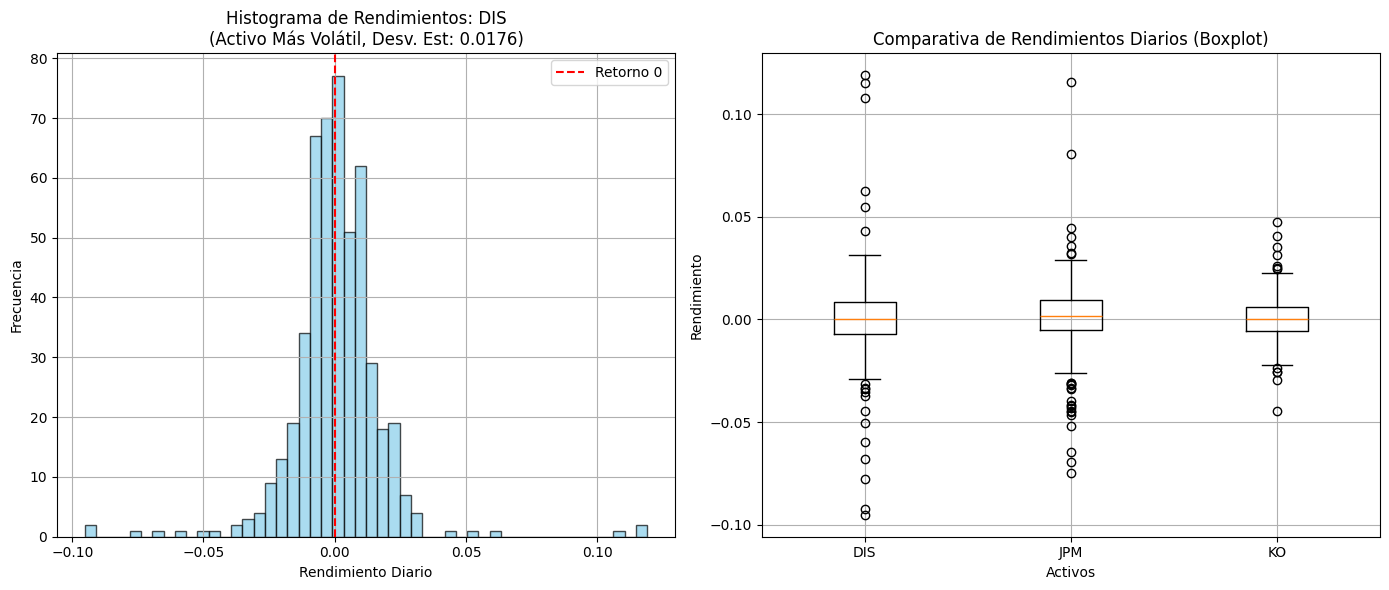

In [36]:
# 1. Calcular rendimientos
rendimiento = precios_cierre.pct_change().dropna()

# Identificar el activo más volátil para el histograma
activo_mas_volatil = rendimiento.std().idxmax()
std_maxima = rendimiento.std().max()

# Configurar la visualización
plt.figure(figsize=(14, 6))

# 2. Histograma con el activo más volátil
plt.subplot(1, 2, 1)
plt.hist(rendimiento[activo_mas_volatil], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', label='Retorno 0')
plt.title(f'Histograma de Rendimientos: {activo_mas_volatil}\n(Activo Más Volátil, Desv. Est: {std_maxima:.4f})')
plt.xlabel('Rendimiento Diario')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)

# 3. Boxplot comparativo de rendimientos
plt.subplot(1, 2, 2)
plt.boxplot([rendimiento[col] for col in rendimiento.columns], labels=rendimiento.columns)
plt.title('Comparativa de Rendimientos Diarios (Boxplot)')
plt.xlabel('Activos')
plt.ylabel('Rendimiento')
plt.grid(True)

plt.tight_layout()
plt.show()

## 📊 Paso 4: Asociación y Correlación

1. Calcula la matriz de correlación de Pearson para los rendimientos de tus 3 activos.
2. Grafica un **mapa de calor (Heatmap)**.

### 💬 Pregunta de interpretación #3:
- ¿Existe alguna correlación fuerte (cercana a 1 o -1) entre alguno de tus activos?
- Si tuvieras que armar un portafolio de inversión buscando la **diversificación** (minimizar el riesgo conjunto), ¿qué par de activos elegirías de acuerdo a tus resultados y por qué?

In [37]:
# 1. Calcular matriz de correlación




# 2. Dibujar el Heatmap utilizando Seaborn

## 🧮 Paso 5: Estadísticas Descriptivas y Conclusión

1. Genera un DataFrame de resumen estadístico que incluya para cada activo: Media, Mediana, Desviación Estándar, Mínimo y Máximo de los rendimientos diarios.
2. Escribe una breve conclusión final dirigida a un inversionista ficticio, interpretando los estadísticos clave obtenidos.

In [38]:
# Generar resumen de estadísticas descriptivas (Media, Mediana, Desviación estándar, Mínimo y Máximo)